# 🏥 Healthcare ML Platform
## Notebook 02 — Exploratory Data Analysis: Diabetes 130-US Hospitals Dataset

**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Rows:** 101,766 hospital admissions  
**Columns:** 50  
**Source:** Kaggle — brandao/diabetes

### What makes this dataset different from Pima
- Much larger — 101k rows vs 768
- Mixed types — numbers AND text columns
- Missing values stored as `"?"` strings — pandas won't detect these automatically
- Has medication columns — used for our **Recommendation module**
- Target has 3 classes — NO / <30 days / >30 days readmission

### What this notebook covers
1. Load and inspect the raw data
2. Find and handle `"?"` missing values
3. Drop columns with too much missing data
4. Understand the medication columns
5. Visualise key distributions
6. Analyse class balance
7. Save cleaned dataset

---
> **Note:** We only keep ~15 of the 50 columns.  
> The rest are either IDs, mostly missing, or not useful for our models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13

print("✓ Libraries ready")

✓ Libraries ready


---
## Step 1 — Load the Data

This dataset is large — 101k rows and 50 columns.  
The first thing we do is load it and check its shape and column names.

**Important:** Missing values in this dataset are stored as the string `"?"`  
not as proper `NaN`. This means `df.isnull().sum()` will show **zero missing values**  
even though thousands of cells are actually empty.  
We need to tell pandas to treat `"?"` as NaN during loading.

In [2]:
# na_values='?' tells pandas to treat "?" as NaN immediately on load
# This is the correct way to handle this dataset
df = pd.read_csv(r'G:\healthcare\Dataset\raw\130_diabetic_data.csv', na_values='?')

print(f"Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nAll 50 column names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

Shape   : 101,766 rows × 50 columns

All 50 column names:
   1. encounter_id
   2. patient_nbr
   3. race
   4. gender
   5. age
   6. weight
   7. admission_type_id
   8. discharge_disposition_id
   9. admission_source_id
  10. time_in_hospital
  11. payer_code
  12. medical_specialty
  13. num_lab_procedures
  14. num_procedures
  15. num_medications
  16. number_outpatient
  17. number_emergency
  18. number_inpatient
  19. diag_1
  20. diag_2
  21. diag_3
  22. number_diagnoses
  23. max_glu_serum
  24. A1Cresult
  25. metformin
  26. repaglinide
  27. nateglinide
  28. chlorpropamide
  29. glimepiride
  30. acetohexamide
  31. glipizide
  32. glyburide
  33. tolbutamide
  34. pioglitazone
  35. rosiglitazone
  36. acarbose
  37. miglitol
  38. troglitazone
  39. tolazamide
  40. examide
  41. citoglipton
  42. insulin
  43. glyburide-metformin
  44. glipizide-metformin
  45. glimepiride-pioglitazone
  46. metformin-rosiglitazone
  47. metformin-pioglitazone
  48. change
  49. diab

---
## Step 2 — Find Missing Values

Now that `"?"` is properly treated as `NaN`,  
let's see which columns have missing data and how much.

We only care about columns with **more than 0%** missing.  
Columns with over **40% missing** will be dropped entirely —  
there's not enough real data to impute reliably.

In [3]:
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)
missing_pct = (missing/len(df) * 100).round(1)

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %' : missing_pct,
    'Action': ['DROP' if p > 40 else 'KEEP/IMPUTE' 
               for p in missing_pct]
}
)
print("Columns with missing values:\n")
print(missing_df.to_string())

Columns with missing values:

                   Missing Count  Missing %       Action
weight                     98569       96.9         DROP
max_glu_serum              96420       94.7         DROP
A1Cresult                  84748       83.3         DROP
medical_specialty          49949       49.1         DROP
payer_code                 40256       39.6  KEEP/IMPUTE
race                        2273        2.2  KEEP/IMPUTE
diag_3                      1423        1.4  KEEP/IMPUTE
diag_2                       358        0.4  KEEP/IMPUTE
diag_1                        21        0.0  KEEP/IMPUTE


---
## Step 3 — Drop Useless Columns

We remove columns for two reasons:

**Reason 1 — Too much missing data**  
`weight`, `payer_code`, `medical_specialty`, `max_glu_serum`, `A1Cresult`  
have 40–97% missing values. Imputing these would be mostly fabrication.

**Reason 2 — Not useful for ML**  
`encounter_id` and `patient_nbr` are just ID numbers.  
They have no predictive value — if we left them in,  
the model might memorise patient IDs instead of learning patterns.

After dropping, we keep the columns that actually matter for our modules.

In [4]:
# Columns to drop
drop_cols = [
    'encounter_id',       # just an ID
    'patient_nbr',        # just an ID
    'weight',             # 97% missing
    'payer_code',         # 40% missing
    'medical_specialty',  # 49% missing
    'max_glu_serum',      # 94% missing
    'A1Cresult',          # 83% missing
]

df_clean = df.drop(columns=drop_cols)


In [5]:
print(f"Columns BEFORE drop : {df.shape[1]}")
print(f"Columns AFTER drop  : {df_clean.shape[1]}")
print(f"\nRemaining columns:")
for col in df_clean.columns:
    print(f"  - {col}")

Columns BEFORE drop : 50
Columns AFTER drop  : 43

Remaining columns:
  - race
  - gender
  - age
  - admission_type_id
  - discharge_disposition_id
  - admission_source_id
  - time_in_hospital
  - num_lab_procedures
  - num_procedures
  - num_medications
  - number_outpatient
  - number_emergency
  - number_inpatient
  - diag_1
  - diag_2
  - diag_3
  - number_diagnoses
  - metformin
  - repaglinide
  - nateglinide
  - chlorpropamide
  - glimepiride
  - acetohexamide
  - glipizide
  - glyburide
  - tolbutamide
  - pioglitazone
  - rosiglitazone
  - acarbose
  - miglitol
  - troglitazone
  - tolazamide
  - examide
  - citoglipton
  - insulin
  - glyburide-metformin
  - glipizide-metformin
  - glimepiride-pioglitazone
  - metformin-rosiglitazone
  - metformin-pioglitazone
  - change
  - diabetesMed
  - readmitted


---
## Step 4 — Handle Remaining Missing Values

After dropping the worst columns, a few others still have some missing values.  
For categorical columns we fill with the **mode** (most frequent value).  
For numeric columns we fill with the **median**.

In [6]:
still_missing = df_clean.isnull().sum()
still_missing = still_missing[still_missing>0]
print("Still missing after dropping bad columns")
print(still_missing)
print()

#Fill categorical columns with mode 

cat_col = df_clean.select_dtypes(include='object').columns

for col in cat_col:
    if df_clean[col].isnull().any():
        mode_val = df_clean[col].mode()[0]
        df_clean[col]= df_clean[col].fillna(mode_val)
        print(f"{col:<30} filled with mode = '{mode_val}'")

num_cols = df_clean.select_dtypes(include=np.number).columns
for col in num_cols:
    if df_clean[col].isnull().any():
        median_val= df_clean[col].median()
        df_clean[col]=df_clean[col].fillna(median_val)
        print(f"{col:<30} filled with median = {median_val}")

print(f"\nTotal missing  after imputation : {df_clean.isnull().sum().sum()}")
        

Still missing after dropping bad columns
race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64

race                           filled with mode = 'Caucasian'
diag_1                         filled with mode = '428'
diag_2                         filled with mode = '276'
diag_3                         filled with mode = '250'

Total missing  after imputation : 0


---
## Step 5 — Understand the Medication Columns

This is what makes the 130-US dataset unique and why we chose it  
for the **Recommendation module**.

Columns like `metformin`, `insulin`, `glipizide` etc. record  
whether a medication was changed during the hospital stay:

| Value | Meaning |
|---|---|
| `No` | Medication not prescribed |
| `Steady` | Prescribed, no change |
| `Up` | Dose increased |
| `Down` | Dose decreased |

For recommendation we interpret `Steady` or `Up` as  
**"this medication was actively used"** for this patient.  
When a new patient arrives, we find similar past patients  
and recommend the medications they used.

We keep a medication column only if it was **actively used in at least 1% of patients**.

Active % = {(Steady + Up + Down) / total patients} × 100

In [7]:
# Check ALL medication columns and their usage rates
all_med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]

print(f"{'Medication':<30} {'No':>8} {'Steady':>8} {'Up':>6} {'Down':>6}  {'Active %':>10}  {'Keep?'}")
print("-" * 85)

keep = []
drop = []

for col in all_med_cols:
    if col not in df_clean.columns:
        continue
    counts = df_clean[col].value_counts()
    no      = counts.get('No', 0)
    steady  = counts.get('Steady', 0)
    up      = counts.get('Up', 0)
    down    = counts.get('Down', 0)
    active  = steady + up + down
    active_pct = active / len(df_clean) * 100

    decision = 'YES' if active_pct >= 1.0 else 'DROP — too rare'

    print(f"{col:<30} {no:>8,} {steady:>8,} {up:>6,} {down:>6,}  {active_pct:>9.1f}%  {decision}")

    if active_pct >= 1.0:
        keep.append(col)
    else:
        drop.append(col)

print(f"\nKeep  ({len(keep)}) : {keep}")
print(f"Drop  ({len(drop)}) : {drop}")


Medication                           No   Steady     Up   Down    Active %  Keep?
-------------------------------------------------------------------------------------
metformin                        81,778   18,346  1,067    575       19.6%  YES
repaglinide                     100,227    1,384    110     45        1.5%  YES
nateglinide                     101,063      668     24     11        0.7%  DROP — too rare
chlorpropamide                  101,680       79      6      1        0.1%  DROP — too rare
glimepiride                      96,575    4,670    327    194        5.1%  YES
acetohexamide                   101,765        1      0      0        0.0%  DROP — too rare
glipizide                        89,080   11,356    770    560       12.5%  YES
glyburide                        91,116    9,274    812    564       10.5%  YES
tolbutamide                     101,743       23      0      0        0.0%  DROP — too rare
pioglitazone                     94,438    6,976    234    118  

In [8]:
med_cols = keep

print("Medication usage across all patients:\n")
print(f"{'Medication':<20} {'No':>8} {'Steady':>8} {'Up':>8} {'Down':>8}  {'Active %':>10}")
print("-" * 68)

for col in med_cols:
    if col not in df_clean.columns:
        continue
    counts = df_clean[col].value_counts()
    no      = counts.get('No', 0)
    steady  = counts.get('Steady', 0)
    up      = counts.get('Up', 0)
    down    = counts.get('Down', 0)
    active_pct = (steady + up + down) / len(df_clean) * 100
    print(f"{col:<20} {no:>8,} {steady:>8,} {up:>8,} {down:>8,}  {active_pct:>9.1f}%")

Medication usage across all patients:

Medication                 No   Steady       Up     Down    Active %
--------------------------------------------------------------------
metformin              81,778   18,346    1,067      575       19.6%
repaglinide           100,227    1,384      110       45        1.5%
glimepiride            96,575    4,670      327      194        5.1%
glipizide              89,080   11,356      770      560       12.5%
glyburide              91,116    9,274      812      564       10.5%
pioglitazone           94,438    6,976      234      118        7.2%
rosiglitazone          95,401    6,100      178       87        6.3%
insulin                47,383   30,849   11,316   12,218       53.4%


---
## Step 6 — Visualise Key Numeric Features

We focus on the numeric columns that we'll use as features  
in both the classification and recommendation models.

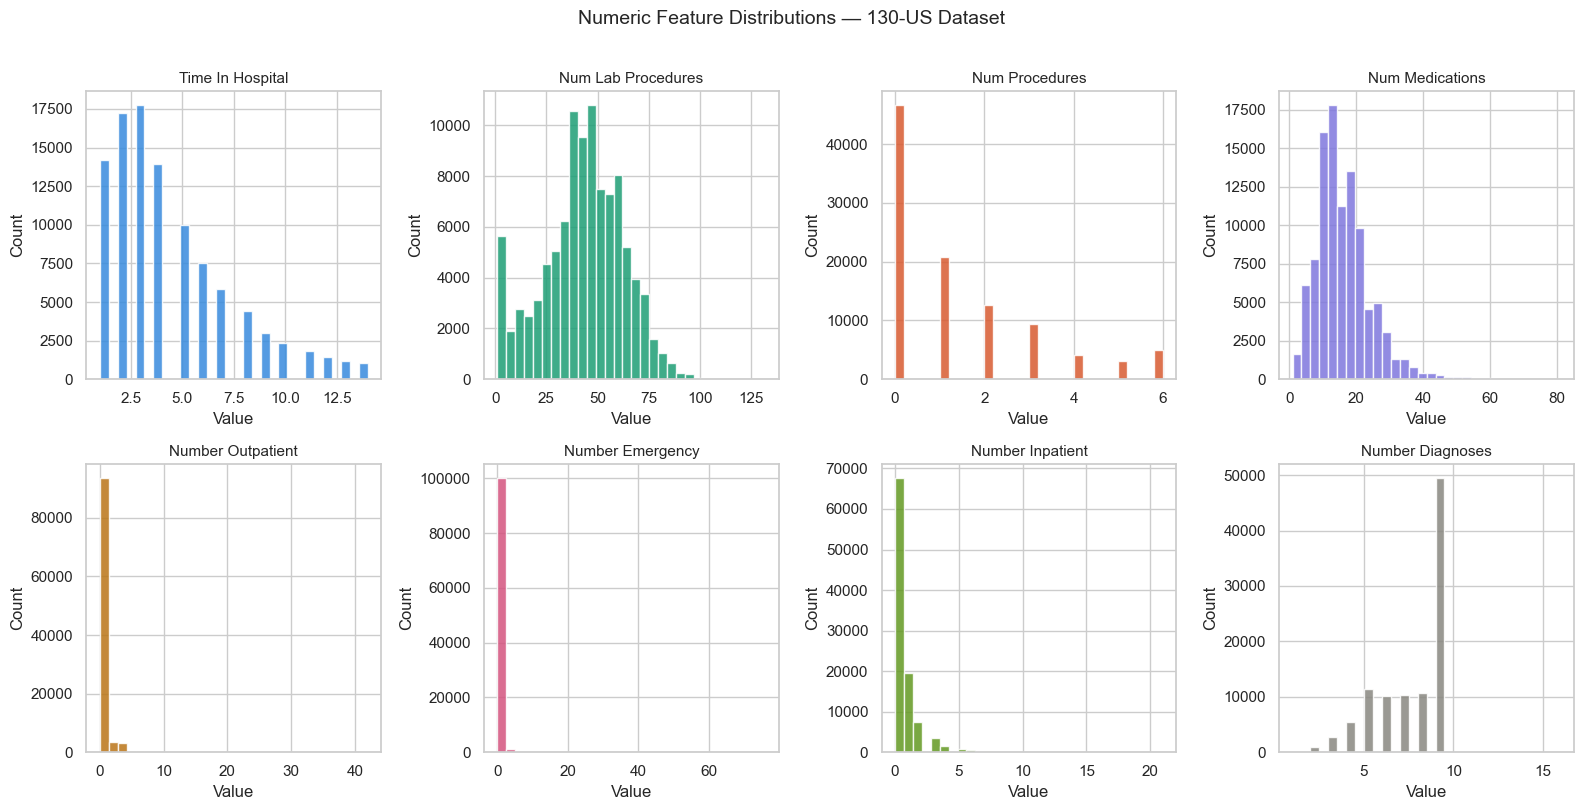

✓ Saved → outputs/130_distributions.png


In [9]:
num_features = ['time_in_hospital', 'num_lab_procedures',
                'num_procedures', 'num_medications',
                'number_outpatient', 'number_emergency',
                'number_inpatient', 'number_diagnoses']

colors = ['#378ADD','#1D9E75','#D85A30','#7F77DD',
          '#BA7517','#D4537E','#639922','#888780']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df_clean[col], bins=30, color=colors[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Numeric Feature Distributions — 130-US Dataset',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/130_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved → outputs/130_distributions.png")

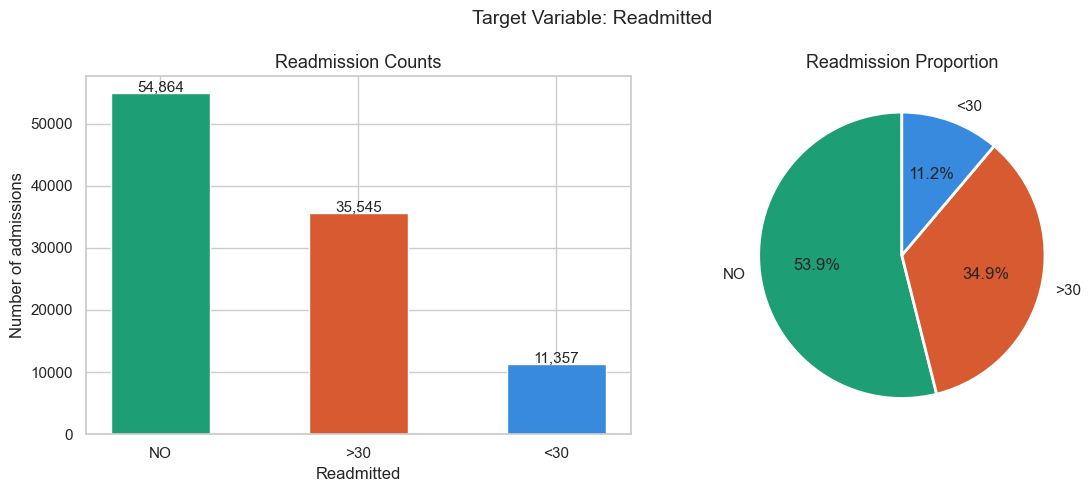

Class distribution:
  NO    : 54,864  (53.9%)
  >30   : 35,545  (34.9%)
  <30   : 11,357  (11.2%)


In [10]:
counts = df_clean['readmitted'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors_bar = ['#1D9E75', '#D85A30', '#378ADD']
bars = axes[0].bar(counts.index, counts.values,
                   color=colors_bar, edgecolor='white', width=0.5)
axes[0].set_title('Readmission Counts')
axes[0].set_ylabel('Number of admissions')
axes[0].set_xlabel('Readmitted')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 val + 200, f'{val:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(counts.values, labels=counts.index,
            colors=colors_bar, autopct='%1.1f%%',
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Readmission Proportion')

plt.suptitle('Target Variable: Readmitted', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/130_class_balance.png', dpi=150)
plt.show()

print("Class distribution:")
for label, count in counts.items():
    print(f"  {label:<5} : {count:>6,}  ({count/len(df_clean)*100:.1f}%)")

---
## Step 8 — Age Distribution

The `age` column is stored as brackets like `[50-60)` not as numbers.  
We convert it to numeric by taking the midpoint of each bracket  
so we can use it in our ML models.

Current age values:
age
[0-10)        161
[10-20)       691
[20-30)      1657
[30-40)      3775
[40-50)      9685
[50-60)     17256
[60-70)     22483
[70-80)     26068
[80-90)     17197
[90-100)     2793
Name: count, dtype: int64

After conversion — age column:
  Min    : 5
  Max    : 95
  Mean   : 66.0


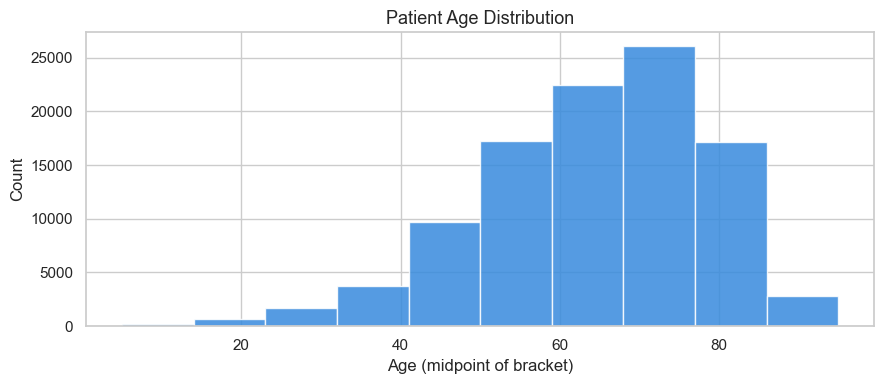

✓ Age column converted to numeric


In [11]:
# Show current age values
print("Current age values:")
print(df_clean['age'].value_counts().sort_index())

# Convert age brackets to numeric midpoints
age_map = {
    '[0-10)'  : 5,  '[10-20)' : 15, '[20-30)' : 25,
    '[30-40)' : 35, '[40-50)' : 45, '[50-60)' : 55,
    '[60-70)' : 65, '[70-80)' : 75, '[80-90)' : 85,
    '[90-100)': 95
}
df_clean['age'] = df_clean['age'].map(age_map)

print(f"\nAfter conversion — age column:")
print(f"  Min    : {df_clean['age'].min()}")
print(f"  Max    : {df_clean['age'].max()}")
print(f"  Mean   : {df_clean['age'].mean():.1f}")

# Plot age distribution
plt.figure(figsize=(9, 4))
plt.hist(df_clean['age'], bins=10, color='#378ADD',
         edgecolor='white', alpha=0.85)
plt.title('Patient Age Distribution')
plt.xlabel('Age (midpoint of bracket)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/130_age_distribution.png', dpi=150)
plt.show()
print("✓ Age column converted to numeric")

---
## Step 9 — Save Cleaned Dataset

We save two versions:

1. **`diabetes130_clean.csv`** — full cleaned dataset for classification model
2. **`treatment_lookup.csv`** — only the columns needed for recommendation  
   (patient features + medication columns)

In [12]:
# Save full cleaned dataset
df_clean.to_csv('../Dataset/processed/diabetes130_clean.csv', index=False)
print(f"✓ Saved → Dataset/processed/diabetes130_clean.csv")
print(f"  Shape : {df_clean.shape}")

# Save treatment lookup for recommendation module
med_cols = ['metformin', 'repaglinide', 'nateglinide', 'glimepiride',
            'glipizide', 'glyburide', 'pioglitazone',
            'rosiglitazone', 'insulin']

feature_cols = ['age', 'time_in_hospital', 'num_lab_procedures',
                'num_procedures', 'num_medications', 'number_diagnoses']

lookup_cols = feature_cols + med_cols
treatment_lookup = df_clean[lookup_cols].copy()
treatment_lookup.to_csv('../Dataset/processed/treatment_lookup.csv', index=False)

print(f"\n Saved → Dataset/processed/treatment_lookup.csv")
print(f"  Shape : {treatment_lookup.shape}")
print(f"  Columns : {list(treatment_lookup.columns)}")

✓ Saved → Dataset/processed/diabetes130_clean.csv
  Shape : (101766, 43)

 Saved → Dataset/processed/treatment_lookup.csv
  Shape : (101766, 15)
  Columns : ['age', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin']


---
## EDA Summary — Key Findings

| Finding | Detail |
|---|---|
| Dataset size | 101,766 rows × 50 columns |
| After cleaning | 101,766 rows × 43 columns |
| Missing value format | Stored as `"?"` — fixed with `na_values='?'` |
| Columns dropped | 7 (IDs + >40% missing) |
| Age column | Converted from brackets to numeric midpoints |
| Target classes | 3 — NO / <30 / >30 |
| Most used medication | Insulin (~53% of patients) |
| Most common age group | 70–80 years |

### Files saved
- `data/processed/diabetes130_clean.csv` ✓
- `data/processed/treatment_lookup.csv` ✓

---
**Next notebook → `03_feature_engineering.ipynb`**